In [ ]:
import pandas as pd

df = pd.read_csv("/cleaned_companies - cleaned_companies.csv")
df.head()

,id,universalName,linkedinUrl,name,tagline,website,phone,logo,founded_year,employeeCount,...,emp_range_end,followerCount,description,locations,specialities,industries,active,pageType,callToActionUrl,description_short
0,12634142,fighting-youth-unemployment,https://www.linkedin.com/company/fighting-yout...,Fighting Youth Unemployment,NaN,https://linktr.ee/fighting.unemployment,NaN,https://media.licdn.com/dms/image/v2/C4E0BAQE-...,2019.0,350.0,...,10,390329,Fighting Youth Unemployment is the marketing b...,"{'country': 'ZA', 'city': 'Morningside Manor',...","Vacancy Advertising, Graduate Recruitment, Per...","{'id': '104', 'name': 'Staffing & Recruiting',...",True,COMPANY,https://linktr.ee/fighting.unemployment,Fighting Youth Unemployment is the marketing b...
1,18974342,ourbloom,https://www.linkedin.com/company/ourbloom/,The Bloom 🌱,The world’s go-to community and newsletter for...,http://readtobloom.com,NaN,https://media.licdn.com/dms/image/v2/D4D0BAQG9...,2020.0,69.0,...,10,40773,"The Bloom is where 80,000+ social and impact c...","{'country': 'GB', 'city': 'London', 'geographi...","Human Rights, Social Impact, Jobs, Coaching, M...","{'id': '68', 'name': 'Higher Education', 'urn'...",True,COMPANY,http://readtobloom.com,"The Bloom is where 80,000+ social and impact c..."
2,28156481,yes4youth,https://www.linkedin.com/company/yes4youth/,Youth Employment Service (YES) South Africa,"Transforming companies, communities and youth ...",https://www.yes4youth.co.za,NaN,https://media.licdn.com/dms/image/v2/D4D0BAQFL...,2017.0,2043.0,...,50,548011,"Transforming companies, communities and youth ...","{'country': 'ZA', 'city': 'Johannesburg', 'geo...","Job Creation, Youth Employment, Inclusive busi...","{'id': '100', 'name': 'Non-profit Organization...",True,COMPANY,https://www.yes4youth.co.za,"Transforming companies, communities and youth ..."
3,22872,golden-key-international-honour-society,https://www.linkedin.com/company/golden-key-in...,Golden Key International Honour Society,"The world's largest honor society, which offer...",http://www.goldenkey.org,NaN,https://media.licdn.com/dms/image/v2/C4E0BAQGm...,1977.0,1865.0,...,50,58484,Golden Key has emerged as one of the most dyna...,"{'country': 'AU', 'city': 'Strawberry Hills NS...",NaN,"{'id': '100', 'name': 'Non-profit Organization...",True,COMPANY,http://www.goldenkey.org,Golden Key has emerged as one of the most dyna...
4,11803952,precisionrecruitmentinternational,https://www.linkedin.com/company/precisionrecr...,Precision Recruitment International,NaN,http://priconsultants.com/,NaN,https://media.licdn.com/dms/image/v2/D4D0BAQF9...,NaN,80.0,...,50,173373,Precision Recruitment International (PRI) is a...,"{'country': 'MZ', 'city': 'Maputo', 'geographi...","Recruitment, Talent Managment, HR Solutions, L...","{'id': '137', 'name': 'Human Resources', 'urn'...",True,COMPANY,http://www.priconsultants.com,Precision Recruitment International (PRI) is a...


Industry Distribution

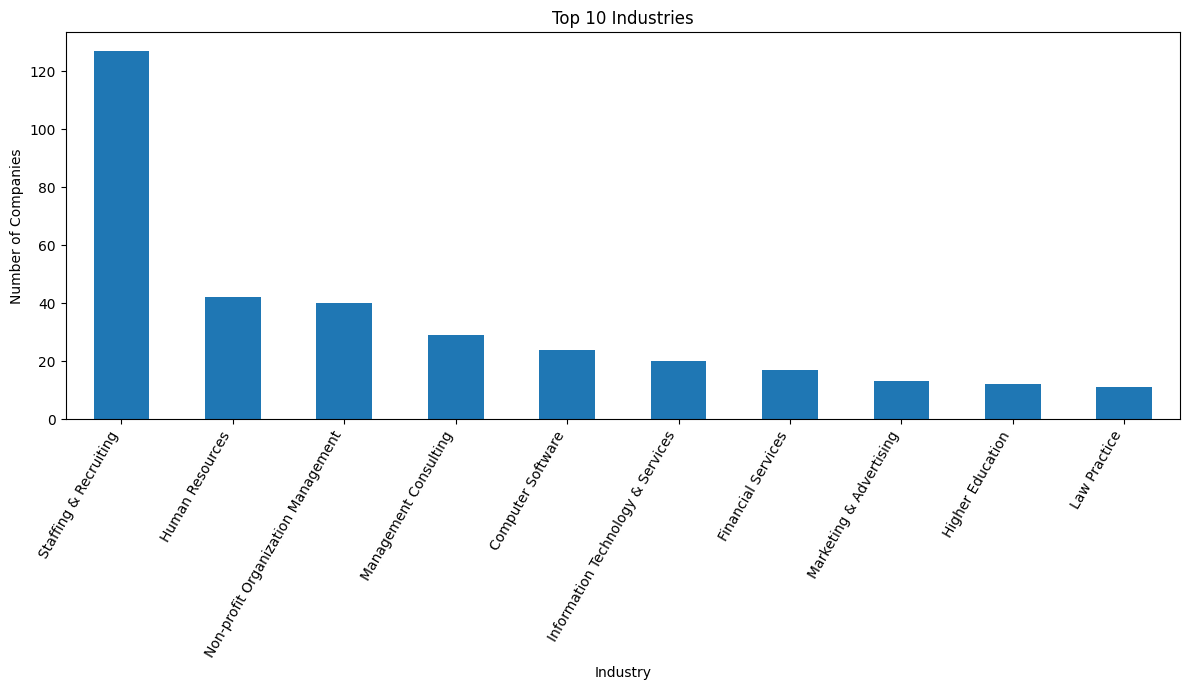

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import ast # Import the ast module to safely evaluate string literals

# df = pd.read_csv("cleaned_companies.csv") # This line is no longer needed as 'df' is already loaded from the previous cell

# Safely extract the 'name' from the 'industries' column
# We'll use apply and ast.literal_eval to parse the stringified dictionary
# Handle potential errors if the string is not a valid dictionary or is NaN
expanded_industries = df['industries'].apply(lambda x: ast.literal_eval(x)['name'] if pd.notna(x) and isinstance(x, str) else None)

industry_counts = expanded_industries.value_counts().head(10)

plt.figure(figsize=(12,7)) # Increased figure size for better label visibility
industry_counts.plot(kind='bar')
plt.title("Top 10 Industries")
plt.xlabel("Industry")
plt.ylabel("Number of Companies")
plt.xticks(rotation=60, ha='right') # Rotate labels more and align right
plt.tight_layout()
plt.show()

Company Size Distribution

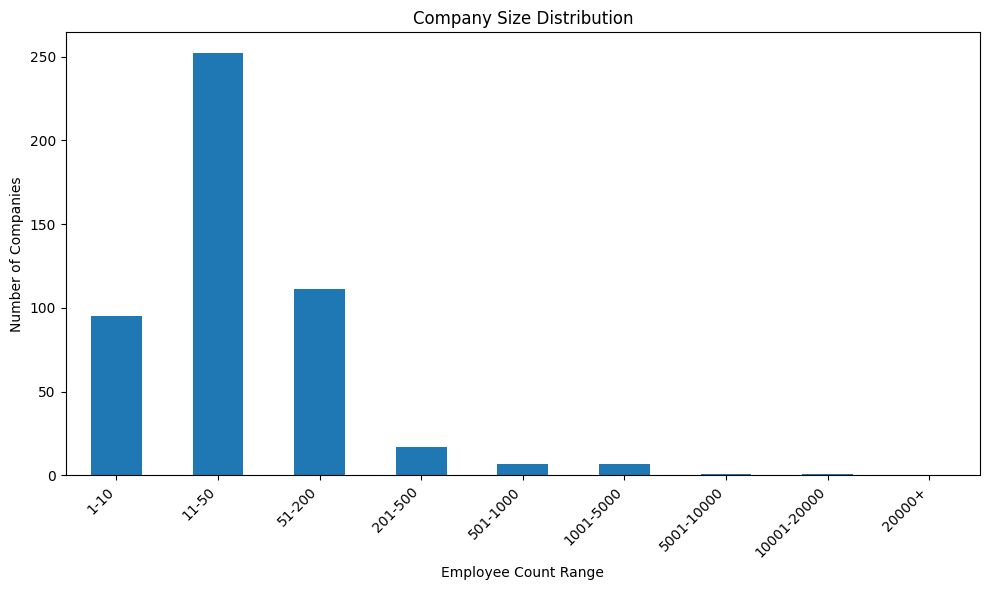

In [ ]:
# The column 'employee_count' does not exist in the DataFrame.
# Please check the available columns in your DataFrame to find the correct one.
# print("Available columns in df:")
# print(df.columns)

# Corrected code using 'employeeCount'
# Define bins for employee count
bins = [0, 10, 50, 200, 500, 1000, 5000, 10000, 20000, float('inf')]
labels = ['1-10', '11-50', '51-200', '201-500', '501-1000', '1001-5000', '5001-10000', '10001-20000', '20000+']

# Create a new column with binned employee counts
df['employee_count_bin'] = pd.cut(df['employeeCount'], bins=bins, labels=labels, right=False)

# Count companies per bin and sort by the bin labels
size_counts_binned = df['employee_count_bin'].value_counts().sort_index()

plt.figure(figsize=(10,6)) # Adjusted figure size
size_counts_binned.plot(kind='bar')
plt.title("Company Size Distribution")
plt.xlabel("Employee Count Range") # Updated x-axis label
plt.ylabel("Number of Companies")
plt.xticks(rotation=45, ha='right') # Rotate and align for better readability
plt.tight_layout()
plt.show()

Followers Distribution

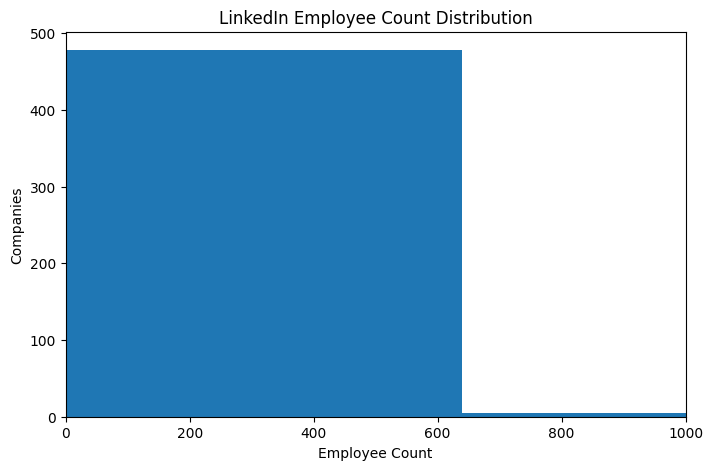

In [ ]:
plt.figure(figsize=(8,5))

plt.hist(df['employeeCount'].dropna(), bins=30)

plt.title("LinkedIn Employee Count Distribution")
plt.xlabel("Employee Count")
plt.ylabel("Companies")
plt.xlim(0, 1000) # Set x-axis limit for better scaling
plt.show()

Industries vs Company Size

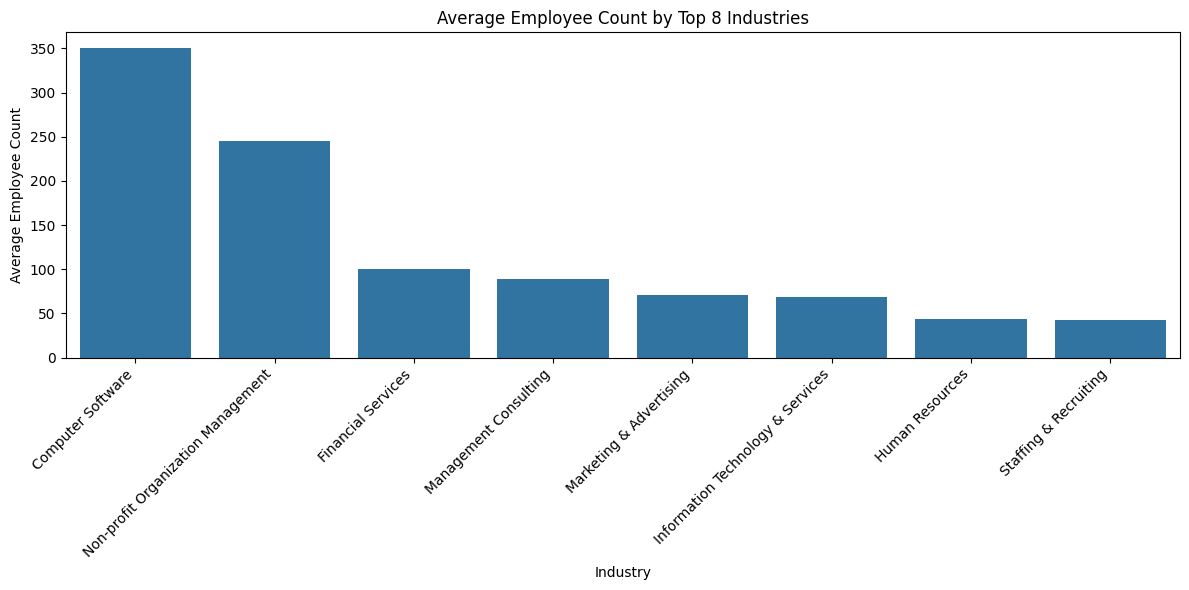

In [ ]:
import seaborn as sns
import pandas as pd # Ensure pandas is imported if not already

# Create a temporary DataFrame for plotting with the correct columns
# We need to make sure the index aligns correctly between df and expanded_industries
plot_df = pd.DataFrame({
    'industry_name': expanded_industries,
    'employeeCount': df['employeeCount']
})

# Filter for the top 8 industries based on expanded_industries
top_8_industries = expanded_industries.value_counts().head(8).index
plot_df_filtered = plot_df[plot_df['industry_name'].isin(top_8_industries)].dropna(subset=['industry_name', 'employeeCount'])

# Calculate the average employee count for each industry
average_employee_count_by_industry = plot_df_filtered.groupby('industry_name')['employeeCount'].mean().sort_values(ascending=False).reset_index()

plt.figure(figsize=(12,6))

sns.barplot(
    data=average_employee_count_by_industry,
    x="industry_name",
    y="employeeCount"
)

plt.xticks(rotation=45, ha='right') # Rotate and align for better readability
plt.title('Average Employee Count by Top 8 Industries') # Update title for bar plot
plt.xlabel('Industry')
plt.ylabel('Average Employee Count') # Update y-axis label
plt.tight_layout() # Adjust layout to prevent labels from overlapping

plt.show()